# Task 1: Linear Regression House Price Predictor

This notebook completes the Artificial Intelligence & Machine Learning Task 1 assignment. It loads the California Housing dataset, performs exploratory data analysis, trains a linear regression model, evaluates it with MAE, RMSE, and R2, and saves the trained model.

## 1. Import libraries

The workflow uses pandas for tabular analysis, scikit-learn for modeling, and matplotlib/seaborn for visualizations.

In [1]:
# Import core libraries for data handling, plotting, modeling, and saving files.
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Use a clean plot style and define reusable project folders.
sns.set_theme(style='whitegrid', palette='deep')
ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'


## 2. Load the California Housing dataset

The target is `MedHouseVal`, the median house value for a California district. scikit-learn stores it in units of 100,000 USD.

In [2]:
# Load the California Housing dataset as a pandas DataFrame.
dataset = fetch_california_housing(data_home=str(DATA_DIR), as_frame=True)
# Rename the target column so its meaning is easier to read in outputs.
df = dataset.frame.copy().rename(columns={'MedHouseVal': 'MedianHouseValue'})
feature_names = list(dataset.feature_names)

# Display the basic dataset size and preview the first rows.
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
df.head()

Rows: 20,640
Columns: 9


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedianHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Explore the data

This step checks data quality, summary statistics, and the distribution of the target variable.

In [3]:
# Check whether any columns contain missing values before training.
print('Missing values per column:')
print(df.isna().sum())

# Review count, mean, spread, and ranges for every numeric column.
df.describe().T

Missing values per column:
MedInc              0
HouseAge            0
AveRooms            0
AveBedrms           0
Population          0
AveOccup            0
Latitude            0
Longitude           0
MedianHouseValue    0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedianHouseValue,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


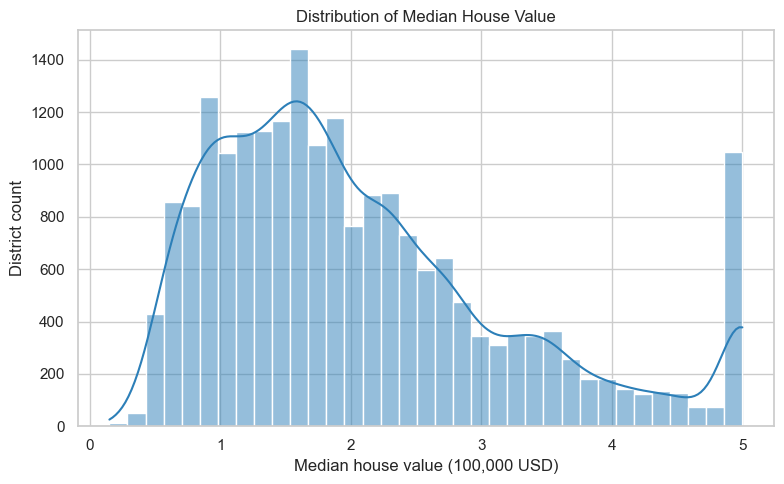

In [4]:
# Plot the target distribution to understand typical and capped house values.
plt.figure(figsize=(8, 5))
sns.histplot(df['MedianHouseValue'], bins=35, kde=True, color='#2c7fb8')
plt.title('Distribution of Median House Value')
plt.xlabel('Median house value (100,000 USD)')
plt.ylabel('District count')
plt.tight_layout()
plt.show()

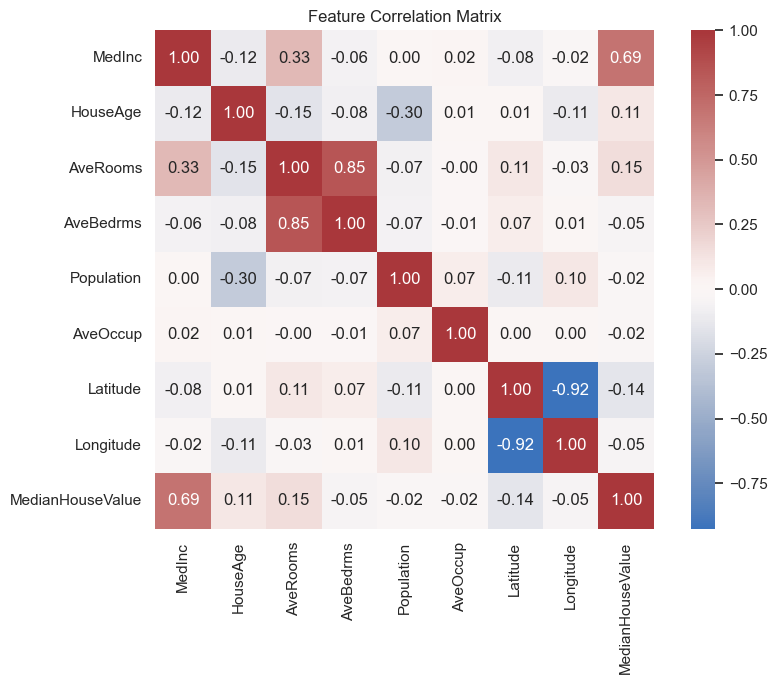

In [5]:
# Correlation helps identify relationships between inputs and the target.
plt.figure(figsize=(9, 7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='vlag', center=0, annot=True, fmt='.2f', square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 4. Train a Linear Regression model

The data is split into training and testing sets. A `StandardScaler` is included so coefficients can be compared on a common scale, followed by `LinearRegression`.

In [6]:
# Separate input features from the target we want to predict.
X = df[feature_names]
y = df['MedianHouseValue']

# Keep 20% of the rows aside for final testing.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# StandardScaler normalizes features; LinearRegression learns the prediction rule.
model = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('linear_regression', LinearRegression()),
    ]
)
# Fit the model on training data, then predict unseen test data.
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(f'Training rows: {len(X_train):,}')
print(f'Testing rows: {len(X_test):,}')

Training rows: 16,512
Testing rows: 4,128


## 5. Evaluate the model

MAE and RMSE are in the same target units as the dataset, meaning 1.0 equals about $100,000. R2 shows the share of test-set variation explained by the model.

In [7]:
# Calculate standard regression metrics on the test set.
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

# Present metrics in a compact table for the report/notebook.
metrics = pd.DataFrame(
    {
        'Metric': ['MAE', 'RMSE', 'R2'],
        'Value': [mae, rmse, r2],
    }
)
metrics

,Metric,Value
0,MAE,0.533200
1,RMSE,0.745581
2,R2,0.575788


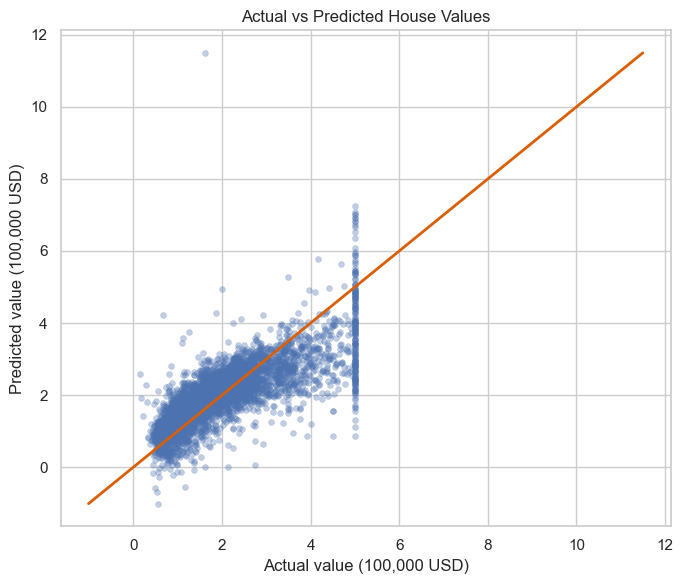

In [8]:
# Compare actual values with predictions; points near the diagonal are better.
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=predictions, s=18, alpha=0.35, edgecolor=None)
low = min(float(y_test.min()), float(predictions.min()))
high = max(float(y_test.max()), float(predictions.max()))
# The diagonal line represents perfect predictions.
plt.plot([low, high], [low, high], color='#d95f02', linewidth=2)
plt.title('Actual vs Predicted House Values')
plt.xlabel('Actual value (100,000 USD)')
plt.ylabel('Predicted value (100,000 USD)')
plt.tight_layout()
plt.show()

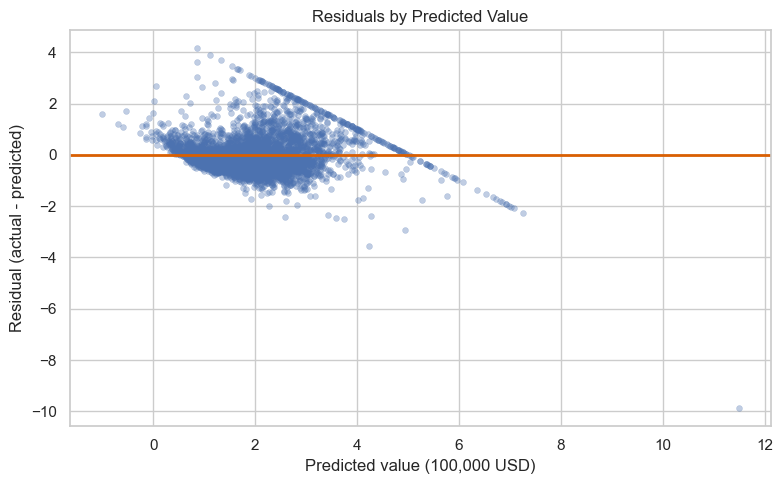

In [9]:
# Residuals show the prediction error for each test example.
residuals = y_test - predictions

plt.figure(figsize=(8, 5))
sns.scatterplot(x=predictions, y=residuals, s=18, alpha=0.35, edgecolor=None)
# A good residual plot should be roughly centered around zero.
plt.axhline(0, color='#d95f02', linewidth=2)
plt.title('Residuals by Predicted Value')
plt.xlabel('Predicted value (100,000 USD)')
plt.ylabel('Residual (actual - predicted)')
plt.tight_layout()
plt.show()

## 6. Interpret coefficients

Because the model uses standardized features, larger absolute coefficients indicate features with stronger influence on the linear model.

In [10]:
# Extract standardized coefficients from the trained linear regression step.
coefficients = pd.DataFrame(
    {
        'feature': feature_names,
        'standardized_coefficient': model.named_steps['linear_regression'].coef_,
    }
# Sort by absolute size so the most influential features appear first.
).sort_values('standardized_coefficient', key=np.abs, ascending=False)

coefficients

,feature,standardized_coefficient
6,Latitude,-0.896929
7,Longitude,-0.869842
0,MedInc,0.854383
3,AveBedrms,0.339259
2,AveRooms,-0.294410
1,HouseAge,0.122546
5,AveOccup,-0.040829
4,Population,-0.002308


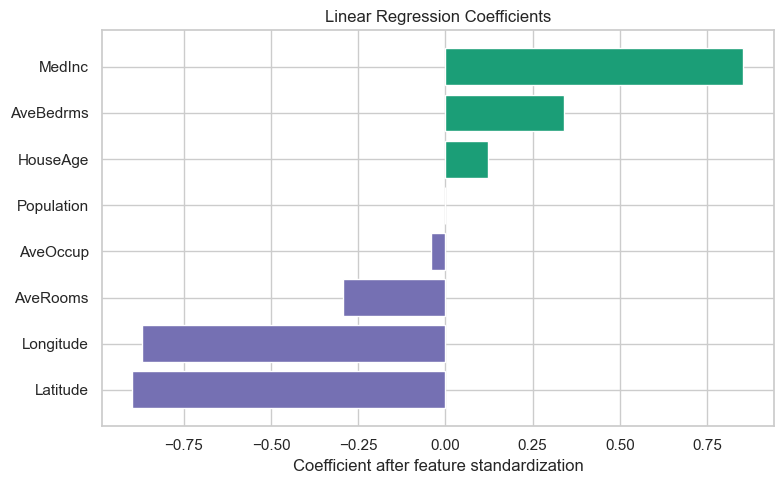

In [11]:
# Sort coefficients for a horizontal bar chart.
ordered = coefficients.sort_values('standardized_coefficient')
# Use different colors to distinguish positive and negative coefficients.
bar_colors = ['#1b9e77' if value > 0 else '#7570b3' for value in ordered['standardized_coefficient']]

plt.figure(figsize=(8, 5))
plt.barh(ordered['feature'], ordered['standardized_coefficient'], color=bar_colors)
plt.title('Linear Regression Coefficients')
plt.xlabel('Coefficient after feature standardization')
plt.tight_layout()
plt.show()

## 7. Improvement ideas

- Try non-linear models such as Random Forest, Gradient Boosting, or HistGradientBoosting.
- Add engineered features, for example rooms per bedroom or location clusters.
- Use cross-validation to estimate performance stability.
- Investigate capped target values and outliers before production use.
- Compare a baseline mean predictor against the trained model.